In [1]:
#!pip install camb

In [19]:
# Main dependencies
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import os
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from datetime import date
from datetime import datetime
import math
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader

# prints number of GPUs available
print(torch.cuda.device_count())

4


In [20]:
# Here we define some important variables used throughout the code
max_stretch = 1.1
num_mocks = 10000     # Number of fiducial Sancho mock galaxy catalogs
field_size = 32       # Number of cells along each axis of galaxy field grid
batch = 100           # Number of fields in a batch
model_type = 'OG'  # 'Simon' or 'OG'
optimize = 'Adam'      # 'SGD', 'Adam', 'SGD_opt_lr', or 'Adam_opt_lr'. '-opt_lr' denotes that the 
                      # learning rates for network parameters have been manually tuned to be optimal
epoch_num = 1000      # How many epochs to train for

In [21]:
# Sancho simulation filenames have the following naming convention
# A_HOD_B_NFW_C_1Gpc_z0.50_D_E.npz
# A is the cosmology (e.g. fiducial)
# B is the HOD set up parameters (e.g. fiducial or " "_p/" "_m for a step above or below the fiducial 
# parameter values)
# C is the ID of the HOD realization (e.g. sample0). For a set of cosmological and HOD parameters, 
# 5 HOD realizations are run
# D is the RSD direction (1, 2, or 3 for x, y, or z)
# E is the ID for the run (e.g. all files in the "0" folder will end in run0). For the fiducial folder,
# ID goes up to 15,000

In [22]:
def grid_galaxies(positions, N, L):
    """
    Parameters
    ----------
    positions : ndarray of shape (Ngal, 3)
        Galaxy positions [x, y, z]
    N : int
        Number of grid cells along each axis
    L : float
        Half the normalized side length of the cube

    Returns
    -------
    counts : ndarray of shape (N, N, N)
        Number of galaxies in each grid cell.
    """

    # Define bin edges
    edges = np.linspace(-L, L, N + 1)

    # 3D histogram
    counts, _ = np.histogramdd(
        positions,
        bins=(edges, edges, edges)
    )

    return counts.astype(int)

In [23]:
# Uncomment if you want to produce a new tensor array of stretched, marginalized galaxy catalogs
'''
norm_bin_gal = np.zeros((num_mocks,field_size,field_size,field_size))  # array of galaxy fields
stretches = np.zeros(num_mocks)  #array of all stretch labels

for i in range(num_mocks):
    # Pick a random stretch between 1/max_stretch and max_stretch
    stretch = np.random.uniform(1 / max_stretch, max_stretch)
    stretches[i] = stretch
    
    # Here we pick RSD in the z-direction for all 10,000 fiducial mocks
    filename = f'/pscratch/sd/a/ajtorres/Marginalized_Galaxy_Catalogs/Quijote_Halo_Fid_HOD0_NFW_1Gpc_z0.5_run{i}.npz'
    cat = np.load(filename)
    pos = cat['pos']
    pos = (pos - 500)/500  # Normalize all positions to be centered at 0, ranging from -1 to 1
    pos[:,2] = pos[:,2]*stretch  # Stretch the z-positions of every galaxy

    # Make a new array with galaxies that have all coordinates in the interval [-1/max_stretch, 1/max_stretch]
    pos_crop = pos[(abs(pos[:,0]) < 1/max_stretch) & (abs(pos[:,1]) < 1/max_stretch) & (abs(pos[:,2]) < 1/max_stretch)]

    # Bin galaxies based on position in a NxNxN grid
    binned_galaxies = grid_galaxies(pos_crop, field_size, 1/max_stretch)

    # Check that number of galaxies is conserved after binning
    #print(len(pos_crop))
    #print(np.sum(binned_galaxies))

    # Normalize arrays such that all values sum to 1. Prevents network from learning based on galaxy number for field
    binned_galaxies = binned_galaxies / np.sum(binned_galaxies)

    # After normalization, make sure there is no super obvious correlation betweens stretch and max array value
    #print(stretch)
    #print(np.max(binned_galaxies))
    #print()

    # Normalize arrays such that most values are of OOM 1
    norm_bin_gal[i] = binned_galaxies / np.mean(binned_galaxies)

Gal_fields = torch.from_numpy(norm_bin_gal)  # array of galaxy fields
labels = torch.from_numpy(stretches)
''';

In [24]:
'''
# Visualize stretching of the galaxy catalogs generated by marginalizing over a
# range of HOD parameter values when converting from Quijote halo catalogs
for i in range(10):
    plt.imshow(Gal_fields[i][0], cmap = 'gray')
    plt.colorbar()
    plt.tight_layout()
    plt.show()
    print(f"Stretch factor is {stretch}")
''';

In [25]:
# I only had to run this code one time. All it does is save the stretched marginalized mocks as numpy
# arrays so that I do not have to create and save new stretched fields every time I want to run
# this code.
'''
Gal_fields = np.zeros((num_mocks, 1, field_size, field_size, field_size))
labels = np.zeros(num_mocks)

for i in range(num_mocks):
    Gal_fields[i][0] = norm_bin_gal[i]
    labels[i] = stretches[i]

np.save("numpy_stretched_marginalized_fields.npy", Gal_fields)
np.save("numpy_marginalized_stretch_values.npy", labels)
''';

In [26]:
Gal_fields = torch.from_numpy(np.load("/global/homes/a/ajtorres/numpy_stretched_marginalized_fields.npy"))
labels = torch.from_numpy(np.load("/global/homes/a/ajtorres/numpy_marginalized_stretch_values.npy"))

In [27]:
from sklearn.model_selection import train_test_split
test_frac = 0.2                          # What proportion of mocks are reserved for validation
train_num = num_mocks * (1 - test_frac)  # Number of training mocks
test_num = num_mocks * test_frac         # Number of validation mocks

# Create arrays to hold training and validation fields as well as their associated labels
fields_train, fields_test, labels_train, labels_test = train_test_split(Gal_fields, labels, 
                                                                        test_size = test_frac, 
                                                                        random_state = 42)

# This class is meant to take arrays of voxel values and labels and prepare them in a state that the 
# dataloader can process and then give to the neural network
class CustomThrimageDataset():
    def __init__(self, labels, data, transforms = False):
        self.labels = labels
        self.data = data
        self.transforms = transforms

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        thrimage = self.data[idx]
        label = self.labels[idx]
        clonethrimage = thrimage.clone()
        if self.transforms:
            clonethrimage = self.transforms(clonethrimage)
        return clonethrimage, label

In [28]:
# Here we actually define the training and testing datasets in a way that the dataloader can process by 
# using the previously defined class
training_thrimages = CustomThrimageDataset(labels_train, fields_train)
testing_thrimages = CustomThrimageDataset(labels_test, fields_test)

# Here we tell the dataloader what datasets we are giving it, how many images we want for each batch of 
# training and whether we want the datasets to be shuffled between "rounds" of training
train_dataloader = DataLoader(training_thrimages, batch_size=batch, shuffle=True)
test_dataloader = DataLoader(testing_thrimages, batch_size=batch, shuffle=True)

In [29]:
if model_type == 'OG':
    # Original neural network architecture that Alex used for his thesis work
    class Net(nn.Module):
        
        def __init__(self):
            super().__init__()
            # 1 input channel, 6 output channels, and kernel of size 5x5x5 (cube since kernel size given by 1 num)
            self.conv11 = nn.Conv3d(1, 6, 5, padding = 2)
            self.conv12 = nn.Conv3d(6, 16, 5, padding = 2)
            self.conv13 = nn.Conv3d(16, 16, 5,  padding = 2)
    
            # "MaxPool3d" defines a 3d kernel of size 2x2x2 that will generate another array from our input array with 
            # values dictated by the max value of the input array within the region of the array covered by the kernel. 
            # A new array is created of 1 less unit height, width, and depth than our input array unless padding is used
            self.pool = nn.MaxPool3d(2, 2)

            # The input to this layer has 16 channels. Each channel has a 3D galaxy field whose size has been halved
            # two times with pooling layers. Thus the total number of values across all 16 channels will be 16 times
            # the number of values in each 3D array
            self.fc1 = nn.Linear(int(16 * (field_size/(2**2))**3) , 1000)
            self.fc2 = nn.Linear(1000, 200)
            self.fc3 = nn.Linear(200, 1)
    
        #Forward describes how the network passes information from the input forward through the network
        def forward(self, x):
            # Specify pass through three convolutional layers each with a ReLU activation function
            x = F.relu(self.conv11(x))
            # These final two convolutional layers are each followed by a max-pooling layer
            x = self.pool(F.relu(self.conv12(x)))
            x = self.pool(F.relu(self.conv13(x)))
    
            # The '1' parameter in the torch.flatten function basically tells to leave the network to leave the 
            # outermost distinction in our data intact. Here, that is the difference between different thrimages 
            # in our batch, so each thrimage is flattened but not mixed together.
            x = torch.flatten(x, 1)
    
            x = F.relu(self.fc1(x))
            x = F.relu(self.fc2(x))
            x = self.fc3(x)
            return x

if model_type == 'Simon':
    depth = 4                            # Depth of fully connected network
    depth_to_width = 4/115               # Optimal depth:width ratio for my network according to Simon 
    width = int(depth / depth_to_width)  # Depth divided by optimal ratio
    kernel_size = 5
    
    class Net(nn.Module):
        
        def __init__(self):
            super().__init__()
            self.conv11 = nn.Conv3d(1, 6, 5, padding = 2)
            self.conv12 = nn.Conv3d(6, 16, 5, padding = 2)
            self.conv13 = nn.Conv3d(16, 16, 5,  padding = 2)
    
            self.pool = nn.MaxPool3d(2, 2)
    
            self.fc_in = nn.Linear(int(16 * (field_size/(2**2))**3) , width)
            self.fc_hid = nn.Linear(width, width)
            self.fc_out = nn.Linear(width, 1)
    
            
            # Draw initial weights and biases from specified probability distributions for each layer
            c_w = 2  # std for weights that will be modified for each layer according to number of nodes in previous layer
            c_b = 0  # std for biases that will be modified for each layer according to number of nodes in previous layer. 
                     # 0 implies a constant distribution (delta function)
    
            # Initial weights/biases for convolutional layers (can also do "kaiming_normal")
            nn.init.kaiming_uniform_(self.conv11.weight, mode='fan_in', nonlinearity='relu')
            if self.conv11.bias is not None:
                nn.init.constant_(self.conv11.bias, 0)
                
            nn.init.kaiming_uniform_(self.conv12.weight, mode='fan_in', nonlinearity='relu')
            if self.conv12.bias is not None:
                nn.init.constant_(self.conv12.bias, 0)
                
            nn.init.kaiming_uniform_(self.conv13.weight, mode='fan_in', nonlinearity='relu')
            if self.conv13.bias is not None:
                nn.init.constant_(self.conv13.bias, 0)
    
            # Initial weights/biases for fully connected layers. Note how the standard deviation for each
            # distribution is divided by the number of nodes in the previous layer of the fully connected
            # network
            nn.init.normal_(self.fc_in.weight, mean=0.0, std= np.sqrt(c_w / (16*(field_size/(2**2))**3)))
            nn.init.constant_(self.fc_in.bias, 0)
    
            nn.init.normal_(self.fc_hid.weight, mean=0.0, std= np.sqrt(c_w/width))
            nn.init.constant_(self.fc_in.bias, 0)
            
            nn.init.normal_(self.fc_out.weight, mean=0.0, std= np.sqrt(c_w/width))
            nn.init.constant_(self.fc_in.bias, 0)
    
        def forward(self, x):
            x = F.relu(self.conv11(x))
            x = self.pool(F.relu(self.conv12(x)))
            x = self.pool(F.relu(self.conv13(x)))
    
            x = torch.flatten(x, 1)
    
            if depth == 3:
                x = F.relu(self.fc_in(x))
                x = F.relu(self.fc_hid(x))
                x = self.fc_out(x)
                
            elif depth == 4:
                x = F.relu(self.fc_in(x))
                x = F.relu(self.fc_hid(x))
                x = F.relu(self.fc_hid(x))
                x = self.fc_out(x)
                
            return x

# Set up the network to be able to be run across multiple GPUs
net = nn.DataParallel(Net())

# Sends the network to the GPU rather than the CPU for faster training
device = torch.device("cuda:0")
net.to(device);

In [30]:
# Defined loss function to be mean square error
criterion = nn.MSELoss()

# 'lr' is the learning rate. This determines how much the values of weights/biases of the network 
# can be changed during each optimization step of training
lr = 0.001

# lam_w is a coefficient for the learning rate of weights in the network in case those should be
# trained at a different rate than the biases
lam_w = 1

#lam_b is a coefficent for the learning rate of the biases in the network
lam_b = 1

'''
Definition of 'momentum' for the SGD optimizer:

Neural networks work by adjusting weights and biases in a direction of parameter space that lowers the 
network's loss. As a hyperparameter, momentum describes how much previous parameter gradients contribute
to the current direction of parameter adjustments. As in, weights and biases are adjusted not just 
considering the current gradient of the loss in parameter space but also previous gradients. A larger
value for the momentum hyperparameter means that previous gradients are more important.
'''

if optimize == 'SGD':
    # Optimizer defined to be standard gradient descent (SGD) with the same learning rate applied to
    # ALL network parameters (weights and biases in every layer)
    optimizer = optim.SGD(net.parameters(), lr=lr, momentum=0.9)
    
elif optimize == 'Adam':
    # Optimizer defined to be the adpative optimizer Adam with the same learning rate applied to
    # ALL network parameters
    optimizer = optim.Adam(net.parameters(), lr = lr)
    
elif optimize == 'SGD_opt_lr':
    optimizer = optim.SGD([
        # We divide the learning rate for the weights by the number of output values for a layer plus 
        # the number of layers of that type. For convolutional layers, this means dividing by the 
        # number of output channels times the cubic kernel size plus 3. We divide the learning rate
        # for biases just by the depth of the fully connected or convolutional part of the network
        {'params': net.module.conv11.weight, 'lr': lr*lam_w / (6*kernel_size**3 + 3)},
        {'params': net.module.conv11.bias, 'lr': lr*lam_b/3},
    
        {'params': net.module.conv12.weight, 'lr': lr*lam_w / (16*kernel_size**3 + 3)},
        {'params': net.module.conv12.bias, 'lr': lr*lam_b/3},
    
        {'params': net.module.conv13.weight, 'lr': lr*lam_w / (16*kernel_size**3 + 3)},
        {'params': net.module.conv13.bias, 'lr': lr*lam_b/3},
        
        {'params': net.module.fc_in.weight, 'lr': lr*lam_w / (depth+width)},
        {'params': net.module.fc_in.bias, 'lr': lr*lam_b/depth},
        
        {'params': net.module.fc_hid.weight, 'lr': lr*lam_w / (depth+width)},
        {'params': net.module.fc_hid.bias, 'lr': lr*lam_b/depth},
        
        {'params': net.module.fc_out.weight, 'lr': lr*lam_w / (depth+width)},
        {'params': net.module.fc_out.bias, 'lr': lr*lam_b/depth}
    ], lr=lr, momentum=0.9)
    
elif optimize == 'Adam_opt_lr':
    optimizer = optim.Adam([
        {'params': net.module.conv11.weight, 'lr': lr*lam_w / (6*kernel_size**3 + 3)},
        {'params': net.module.conv11.bias, 'lr': lr*lam_b/3},
    
        {'params': net.module.conv12.weight, 'lr': lr*lam_w / (16*kernel_size**3 + 3)},
        {'params': net.module.conv12.bias, 'lr': lr*lam_b/3},
    
        {'params': net.module.conv13.weight, 'lr': lr*lam_w / (16*kernel_size**3 + 3)},
        {'params': net.module.conv13.bias, 'lr': lr*lam_b/3},
        
        {'params': net.module.fc_in.weight, 'lr': lr*lam_w / (depth+width)},
        {'params': net.module.fc_in.bias, 'lr': lr*lam_b/depth},
        
        {'params': net.module.fc_hid.weight, 'lr': lr*lam_w / (depth+width)},
        {'params': net.module.fc_hid.bias, 'lr': lr*lam_b/depth},
        
        {'params': net.module.fc_out.weight, 'lr': lr*lam_w / (depth+width)},
        {'params': net.module.fc_out.bias, 'lr': lr*lam_b/depth}
    ], lr=lr)

else:
    print("Invalid optimizer specified. Please choose either Adam, SGD, Adam_opt_lr, or SGD_opt_lr\
    as an optimizer.")

In [31]:
today = date.today()

# Initialize arrays that we will use to make loss plots later
epochs = np.zeros(epoch_num)
train_loss = np.zeros(epoch_num)
val_loss = np.zeros(epoch_num)

# We will use 'best_loss' so that we can save a copy of the network with the lowest loss
best_loss = np.inf

s = datetime.now()

# Loop over the dataset an epoch_num of times
for epoch in range(epoch_num):
    train_running_loss = 0.0
    test_running_loss = 0.0
    test_running_loss_avg = 0.0
    # Enumerate assigns each entry in train_dataloader, a single batch, to the variable 'data' 
    # 'i' is an index each batch in train_dataloader
    
    for i, data in enumerate(train_dataloader):
        # 'inputs' is a list of all the thrimages in the batch and 'labels' is a list of all 
        # the stretch factors in the batch
        inputs = data[0].to(device)
        labels = data[1].to(device)
        
        #zero the parameter gradients between batches ran through the network so that they don't blow up
        optimizer.zero_grad()
        
        ##This block contains our forward + backward + optimize steps##
        
        # Convert the thrimage tensors into the float32 tensor type
        inputs = inputs.float()
        
        # Run thrimages through network and get the network's guess for the stretch factor for each 
        # thrimage in the batch
        outputs = net(inputs)
        
        # "Squeeze" out any single value arrays (get rid of unneeded brackets)
        outputs = outputs.squeeze()
        
        # Ensure output is a float32 value
        outputs = outputs.float()
        
        # Ensure labels are float32
        labels = labels.float()
        
        # Compute loss, just the square of the difference between the actual stretch factor and what 
        # the network guess is
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_running_loss += loss.item()
        '''
        This segment of code effectively checks if we have ran through the entire image dataset 
        during training. It does this by checking if the number of batches loaded is equal to the 
        number of batches the dataset can be divided into rounded up. It then prints the ith iteration 
        through the dataset that we are currently on and the average loss per image for that iteration
        through the dataset
        '''
        if i + 1 == math.ceil(train_num/batch):
            # Averages running_loss over all the batches in one iteration of the dataset
            train_avg_loss = np.sqrt(train_running_loss/(i+1))
            print(f'[{epoch + 1}] loss: {train_avg_loss:.6f}')
            train_loss[epoch] = train_avg_loss
            
    # This is where we determine the accuracy of the network on the validation dataset We save a 
    # copy of the neural network with the lowest loss 
    for j, data in enumerate(test_dataloader):
        inputs = data[0].to(device)
        labels = data[1].to(device)
        inputs = inputs.float()
        outputs = net(inputs)
        outputs = outputs.squeeze()
        outputs = outputs.float()
        labels = labels.float()
        loss = criterion(outputs, labels)
        test_running_loss += loss.item()
        
        if j + 1 == math.ceil(test_num/batch):
            test_avg_loss = test_running_loss/(j+1)
            print("Average deviation of network guess from actual stretch is approximately: " + str("{0:.3f}".format(np.sqrt(test_avg_loss))))
            epochs[epoch] = epoch
            val_loss[epoch] = np.sqrt(test_avg_loss)

            if test_avg_loss < best_loss:
                best_loss = test_avg_loss
                model_path = f'nnet_Simon_Sancho_{today}.pth'
                # Uncomment to save the network
                torch.save(net.state_dict(), model_path)
                

print('Finished Training')
e = datetime.now()

elapsed = (e - s).total_seconds() 
print("Elapsed:", elapsed, "s")

[1] loss: 0.619350
Average deviation of network guess from actual stretch is approximately: 0.056
[2] loss: 0.055235
Average deviation of network guess from actual stretch is approximately: 0.056
[3] loss: 0.055488
Average deviation of network guess from actual stretch is approximately: 0.055
[4] loss: 0.055834
Average deviation of network guess from actual stretch is approximately: 0.057
[5] loss: 0.056150
Average deviation of network guess from actual stretch is approximately: 0.055
[6] loss: 0.056438
Average deviation of network guess from actual stretch is approximately: 0.059
[7] loss: 0.056027
Average deviation of network guess from actual stretch is approximately: 0.060
[8] loss: 0.056247
Average deviation of network guess from actual stretch is approximately: 0.056
[9] loss: 0.056677
Average deviation of network guess from actual stretch is approximately: 0.055
[10] loss: 0.056080
Average deviation of network guess from actual stretch is approximately: 0.054
[11] loss: 0.056965

KeyboardInterrupt: 

In [15]:
np.save("marg_train_loss.npy", train_loss)
np.save("marg_val_loss.npy", val_loss)

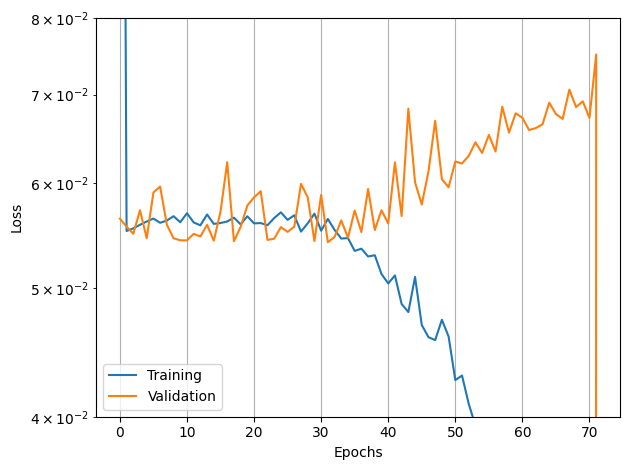

In [32]:
plt.semilogy(epochs, train_loss, label = "Training")
plt.semilogy(epochs, val_loss, label = "Validation")
#plt.title(f"Sancho Mocks, Num Fields = {num_mocks}, Model Number is {model_num}")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.ylim(0.04, 0.08)
plt.grid()
plt.legend()
plt.tight_layout()
#plt.savefig(f"Sancho_fiducial_{epoch_num}_{optimize}.pdf")

In [19]:
print(np.sqrt(best_loss))

0.03746649277674079
